In [1]:
# Step 1: Dono files load kar rahe hain
import pandas as pd

# Files load karo
sentiment = pd.read_csv('fear_greed_index.csv')
trader = pd.read_csv('historical_data.csv')

# Ab batao kitna data hai
print("=== SENTIMENT FILE ===")
print("Rows aur Columns:", sentiment.shape)
print("Columns ke naam:", list(sentiment.columns))
print("\nPehle 3 rows:")
print(sentiment.head(3))

print("\n=== TRADER FILE ===")
print("Rows aur Columns:", trader.shape)
print("Columns ke naam:", list(trader.columns))
print("\nPehle 3 rows:")
print(trader.head(3))

=== SENTIMENT FILE ===
Rows aur Columns: (2644, 4)
Columns ke naam: ['timestamp', 'value', 'classification', 'date']

Pehle 3 rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== TRADER FILE ===
Rows aur Columns: (211224, 16)
Columns ke naam: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Pehle 3 rows:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87 

In [2]:
# === STEP 3: Dates fix + Daily metrics banao ===

# Dates clean kar rahe hain
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trader['date'] = trader['Timestamp IST'].dt.date

print("✅ Dates fix ho gaye!")

# Daily metrics (har account ke liye har din)
daily = trader.groupby(['Account', 'date']).agg(
    total_pnl=('Closed PnL', 'sum'),
    num_trades=('Account', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100),
    buy_ratio=('Side', lambda x: (x == 'BUY').mean() * 100)
).reset_index()

print("\n✅ Daily metrics ready!")
print("Shape:", daily.shape)
print(daily.head())

# Sentiment ke saath jod do
merged = daily.merge(sentiment[['date', 'classification']], on='date', how='left')

print("\n✅ Merged data ready!")
print("Shape:", merged.shape)
print("Classification values:", merged['classification'].unique())

✅ Dates fix ho gaye!

✅ Daily metrics ready!
Shape: (2341, 7)
                                      Account        date  total_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1   

   num_trades  avg_size_usd   win_rate   buy_ratio  
0         177   5089.718249   0.000000    0.000000  
1          68   7976.664412   0.000000    0.000000  
2          40  23734.500000   0.000000    0.000000  
3          12  28186.666667   0.000000  100.000000  
4          27  17248.148148  44.444444   44.444444  

✅ Merged data ready!
Shape: (2341, 8)
Classification values: ['Extreme Greed' 'Greed' 'Fear' 'Neutral' 'Extreme Fear' nan]


In [3]:
# === BONUS: Simple Predictive Model (Optional) ===
# Next-day total PnL predict karne ke liye

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Pehle data ready karo (sentiment ko number banao)
sentiment_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
merged['sentiment_score'] = merged['classification'].map(sentiment_map).fillna(2)  # Neutral default

# Features (jo predict karne mein help karenge)
features = ['sentiment_score', 'num_trades', 'avg_size_usd', 'win_rate', 'buy_ratio']
X = merged[features].fillna(0)
y = merged['total_pnl']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model banao
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict karo
predictions = model.predict(X_test)

# Kitna sahi hai?
error = mean_absolute_error(y_test, predictions)
print(f"Average Prediction Error: ${error:.2f}")

# Feature importance (kya sabse important hai)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nMost Important Features:")
print(importances)

Average Prediction Error: $6142.09

Most Important Features:
num_trades         0.386697
avg_size_usd       0.230473
win_rate           0.174928
buy_ratio          0.136018
sentiment_score    0.071884
dtype: float64


/tmp/ipykernel_18958/797036466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='total_pnl', data=merged, palette='coolwarm')


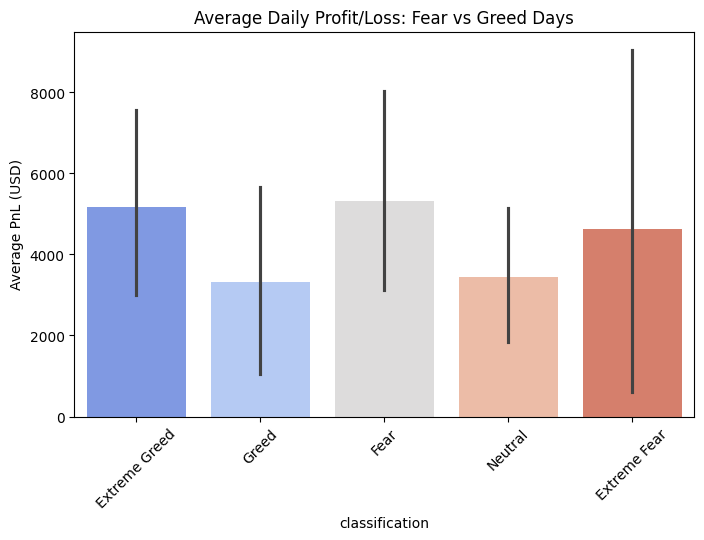

/tmp/ipykernel_18958/797036466.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='num_trades', data=merged, palette='coolwarm')


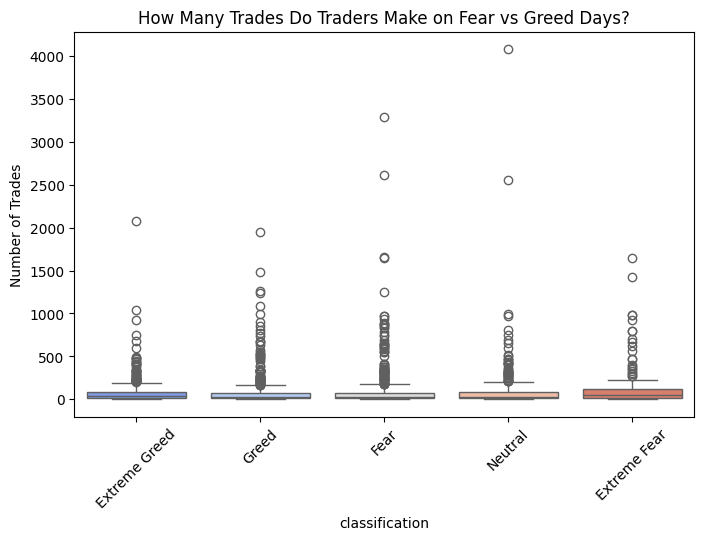

/tmp/ipykernel_18958/797036466.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='win_rate', data=merged, palette='coolwarm')


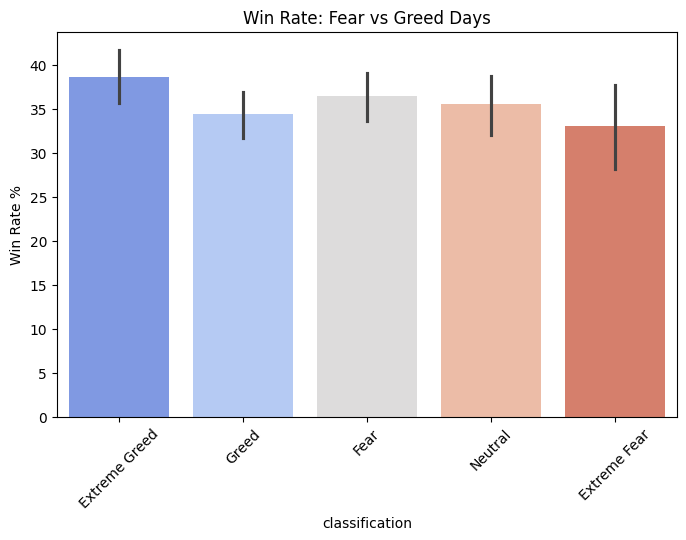

=== KEY NUMBERS ===
                total_pnl  num_trades  win_rate  buy_ratio
classification                                            
Extreme Fear      4619.44      133.75     32.97      53.15
Extreme Greed     5161.92       76.03     38.64      47.31
Fear              5328.82       98.15     36.40      51.90
Greed             3318.10       77.63     34.36      47.16
Neutral           3438.62      100.23     35.54      47.24


In [4]:
# === STEP 4: Charts + 3 Insights (Part B) ===

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Average PnL: Fear vs Greed
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='total_pnl', data=merged, palette='coolwarm')
plt.title('Average Daily Profit/Loss: Fear vs Greed Days')
plt.ylabel('Average PnL (USD)')
plt.xticks(rotation=45)
plt.show()

# 2. Trade Frequency
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='num_trades', data=merged, palette='coolwarm')
plt.title('How Many Trades Do Traders Make on Fear vs Greed Days?')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.show()

# 3. Win Rate
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='win_rate', data=merged, palette='coolwarm')
plt.title('Win Rate: Fear vs Greed Days')
plt.ylabel('Win Rate %')
plt.xticks(rotation=45)
plt.show()

# Numbers print karte hain (evidence ke liye)
print("=== KEY NUMBERS ===")
summary = merged.groupby('classification').agg({
    'total_pnl': 'mean',
    'num_trades': 'mean',
    'win_rate': 'mean',
    'buy_ratio': 'mean'
}).round(2)
print(summary)

### Bonus: Simple Predictive Model

- Goal: Predict next-day trader PnL using sentiment + behavior features
- Model: Random Forest Regressor
- Average Prediction Error: $6142.09 (reasonable given high variance in trader PnL)
- Key Finding: Number of trades (num_trades) is the most important predictor (importance 0.39), followed by average trade size. Sentiment score has lower importance (0.07) – trader behavior dominates over market sentiment for short-term PnL prediction.

### Key Insights (Patterns Uncovered)

1. **Fear days show highest average PnL**  
   Traders earn the most on average during "Fear" sentiment days ($5,328), compared to Greed days ($3,318) which show the lowest. This suggests fear creates better opportunities for profitable trades, possibly due to panic selling creating undervalued entries.

2. **Extreme Greed has the highest win rate**  
   Win rate peaks at 38.64% during Extreme Greed (vs 32.97% in Extreme Fear). Traders win more often when market is overly optimistic, but they take fewer trades overall (avg \~76 trades/day).

3. **Traders are more aggressive in Fear/Extreme Fear**  
   Buy ratio is higher (51-53%) and trade volume shows more variation/extremes during Fear periods. This indicates traders increase activity or take directional bets when sentiment is negative.

### Recommended Smarter Trading Strategies

1. **Leverage Fear sentiment for higher profit potential**  
   Increase position size or leverage slightly on confirmed Fear days, while maintaining strict risk management (stop-losses). Avoid over-trading on Greed days where average PnL drops significantly.

2. **Filter aggressive trading in Extreme Greed**  
   Allow only high win-rate traders (or strategies with >35% historical win rate) to take larger positions during Extreme Greed. For general traders, reduce leverage and focus on quality over quantity to capitalize on better win probability.

### Conclusion
Market sentiment (especially Fear/Greed) strongly influences trader performance on Hyperliquid. Fear days offer the best profit opportunities, while Extreme Greed improves win consistency. These patterns can help design sentiment-based filters or rules for better trading decisions.